This file recreates Fig.5 in Tan25 paper with two methods:

a) Following exactly the same method as in Tan25. That is, same f(n) -or very similar, obtained from pyigm-, same redshift (z=2.29) and same definition of FvoigtHCD (Eq.B22 in overleaf, or Eq.3.3 in Tan25)

b) Following methodology from MW11. That is, different definition of FvoigtHCD (called W2 in MW11, Eq.B3 in MW11, or Eq.b4 in overleaf), different column density distribution (the one defined in Mw11 as a two slope relation), but same redshift as Tan25 (z=2.29)

WARNING: This code expects to be given the path to were the pyigm f(n) values are stored. The user should change my path to their respective path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from picca import constants
import h5py
from scipy import constants as scipy_constants

import sys
import os
sys.path.append(os.path.abspath(".."))
from w1_w2 import wave_to_fft_profile, resample_to_logk

In [15]:
# Tan cosmology values
hubble, z = 0.71, 2.29
omegam, omegab = 0.3147, 0.046
omegal = 1 - omegam
ns = 0.96

# Following Tan25

In [ ]:
data_vega = np.loadtxt('/Users/lflores/Documents/Research/phd/hcd/work_in_progress/Comparisons/fn_nomasking.txt')
integral = np.trapezoid(data_vega[0], data_vega[1])
print(integral)
data_vega[0] /= integral  # Normalizing to the area (without this step, the area is somewhat different than 1)

0.9755411304884455


We define different NHi ranges

In [25]:
NHirange1 = np.linspace(17.3, 18.3, 50)
NHirange2 = np.linspace(18.3, 19.3, 50)
NHirange3 = np.linspace(19.3, 20.3, 50)
NHirange4 = np.linspace(20.3, 21.3, 50)
NHirange5 = np.linspace(21.3, 22.5, 50)
NHirange6 = np.linspace(17.3, 22.5, 50)
NHirange7 = np.linspace(17.3, 20.3, 50)

In [26]:
fn_vega1 = np.interp(NHirange1, data_vega[1], data_vega[0])  
fn_vega2 = np.interp(NHirange2, data_vega[1], data_vega[0])  
fn_vega3 = np.interp(NHirange3, data_vega[1], data_vega[0])  
fn_vega4 = np.interp(NHirange4, data_vega[1], data_vega[0])  
fn_vega5 = np.interp(NHirange5, data_vega[1], data_vega[0])  
fn_vega6 = np.interp(NHirange6, data_vega[1], data_vega[0])  
fn_vega7 = np.interp(NHirange7, data_vega[1], data_vega[0])  


In [27]:
import lace.cosmo.camb_cosmo as camb_cosmo
from lace.cosmo.camb_cosmo import dAA_dMpc as dAA_dMpc_func
cosmocamb = camb_cosmo.get_cosmology(H0=100*hubble, omch2=omegam*(hubble**2), ombh2=omegab*(hubble**2),  ns=ns)
rho_hcd = 0.00158*dAA_dMpc_func(cosmo=cosmocamb, z=z, lambda_AA=1215.67) # Mpc^-1 for z = 2.29 (Tan25)

wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log

In [28]:
w2_int = []
for i, nhi_value in enumerate(NHirange1):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega1[i]*d)

w2_int = np.array(w2_int)
w2_vega1 = rho_hcd*np.trapezoid(w2_int, NHirange1, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange2):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega2[i]*d)

w2_int = np.array(w2_int)
w2_vega2 = rho_hcd*np.trapezoid(w2_int, NHirange2, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange3):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega3[i]*d)

w2_int = np.array(w2_int)
w2_vega3 = rho_hcd*np.trapezoid(w2_int, NHirange3, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange4):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega4[i]*d)

w2_int = np.array(w2_int)
w2_vega4 = rho_hcd*np.trapezoid(w2_int, NHirange4, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange5):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega5[i]*d)

w2_int = np.array(w2_int)
w2_vega5 = rho_hcd*np.trapezoid(w2_int, NHirange5, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange6):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega6[i]*d)

w2_int = np.array(w2_int)
w2_vega6 = rho_hcd*np.trapezoid(w2_int, NHirange6, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange7):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fn_vega7[i]*d)

w2_int = np.array(w2_int)
w2_vega7 = rho_hcd*np.trapezoid(w2_int, NHirange7, axis=0)

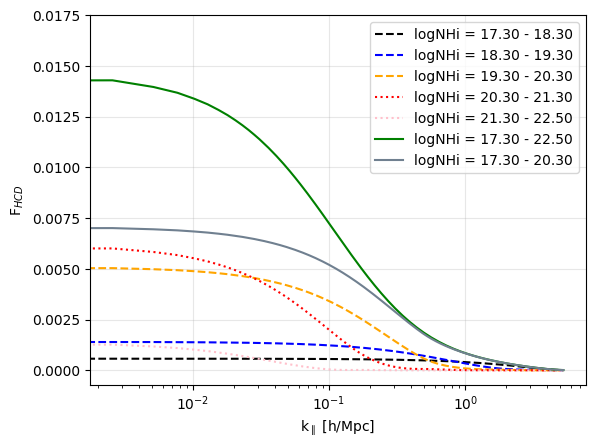

In [29]:

plt.plot(k_w1w2*hubble, w2_vega1, color='k', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange1.min(), NHirange1.max()))
plt.plot(k_w1w2*hubble, w2_vega2, color='b', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange2.min(), NHirange2.max()))
plt.plot(k_w1w2*hubble, w2_vega3, color='orange', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange3.min(), NHirange3.max()))
plt.plot(k_w1w2*hubble, w2_vega4, color='r', linestyle=':', label=r'logNHi = %.2f - %.2f' %(NHirange4.min(), NHirange4.max()))
plt.plot(k_w1w2*hubble, w2_vega5, color='pink', linestyle=':', label=r'logNHi = %.2f - %.2f' %(NHirange5.min(), NHirange5.max()))
plt.plot(k_w1w2*hubble, w2_vega6, color='green', label=r'logNHi = %.2f - %.2f' %(NHirange6.min(), NHirange6.max()))
plt.plot(k_w1w2*hubble, w2_vega7, color='slategrey', label=r'logNHi = %.2f - %.2f' %(NHirange7.min(), NHirange7.max()))
plt.yticks([0.000, 0.0025, 0.0050, 0.0075, 0.0100, 0.0125, 0.0150, 0.0175])
plt.ylabel(r'F$_{HCD}$')
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.legend()
plt.xscale('log')
plt.grid(alpha=0.3)

Tan25 does not specify the cosmology used. That would change the value of rho_hcd, so maybe that is the source of disagreenment. Also, their Fig.5 is made with mocks that follow a nhi distribution similar but not exactly the same as in pyigm.

# Following MW11

In [30]:
def f_Nhi(colden, k, b):
    y = k*(colden**b)
    return y

k1, b1 = 280.14, -1.2
k2, b2 = 4.24e14, -1.8

We define different NHi ranges

In [31]:
NHirange1 = np.linspace(17.3, 18.3, 50)
NHirange2 = np.linspace(18.3, 19.3, 50)
NHirange3 = np.linspace(19.3, 20.3, 50)
NHirange4 = np.linspace(20.3, 21.3, 50)
NHirange5 = np.linspace(21.3, 22.5, 50)
NHirange6 = np.linspace(17.3, 22.5, 50)
NHirange7 = np.linspace(17.3, 20.3, 50)

In [32]:
colden1, colden2 = NHirange1[NHirange1 < 20.3], NHirange1[NHirange1 >= 20.3]
fnhi_mw11_1 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange2[NHirange2 < 20.3], NHirange2[NHirange2 >= 20.3]
fnhi_mw11_2 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange3[NHirange3 < 20.3], NHirange3[NHirange3 >= 20.3]
fnhi_mw11_3 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange4[NHirange4 < 20.3], NHirange4[NHirange4 >= 20.3]
fnhi_mw11_4 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange5[NHirange5 < 20.3], NHirange5[NHirange5 >= 20.3]
fnhi_mw11_5 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange6[NHirange6 < 20.3], NHirange6[NHirange6 >= 20.3]
fnhi_mw11_6 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

colden1, colden2 = NHirange7[NHirange7 < 20.3], NHirange7[NHirange7 >= 20.3]
fnhi_mw11_7 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

In [33]:
import lace.cosmo.camb_cosmo as camb_cosmo
from lace.cosmo.camb_cosmo import dAA_dMpc as dAA_dMpc_func
cosmocamb = camb_cosmo.get_cosmology(H0=100*hubble, omch2=omegam*(hubble**2), ombh2=omegab*(hubble**2), ns=ns)
rho_hcd = 0.00158*dAA_dMpc_func(cosmo=cosmocamb, z=z, lambda_AA=1215.67) # Mpc^-1 for z = 2.29 (Tan25)

wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log

In [34]:
w2_int = []
for i, nhi_value in enumerate(NHirange1):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_1[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_1 = rho_hcd*np.trapezoid(w2_int, NHirange1, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange2):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_2[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_2 = rho_hcd*np.trapezoid(w2_int, NHirange2, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange3):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_3[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_3 = rho_hcd*np.trapezoid(w2_int, NHirange3, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange4):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_4[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_4 = rho_hcd*np.trapezoid(w2_int, NHirange4, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange5):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_5[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_5 = rho_hcd*np.trapezoid(w2_int, NHirange5, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange6):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_6[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_6 = rho_hcd*np.trapezoid(w2_int, NHirange6, axis=0)

w2_int = []
for i, nhi_value in enumerate(NHirange7):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int.append(fnhi_mw11_7[i]*d*np.log(10)*(10**nhi_value))

w2_int = np.array(w2_int)
w2_mw11_7 = rho_hcd*np.trapezoid(w2_int, NHirange7, axis=0)

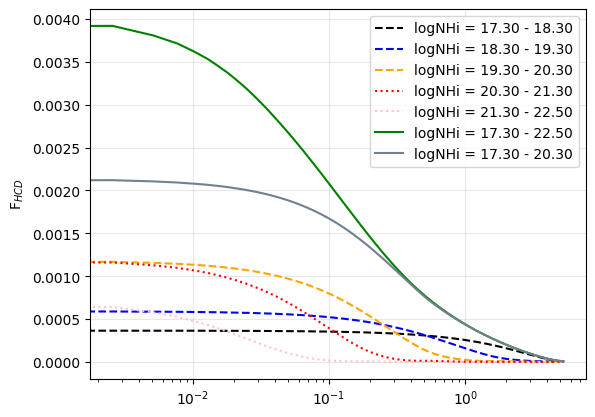

In [35]:

plt.plot(k_w1w2*hubble, w2_mw11_1, color='k', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange1.min(), NHirange1.max()))
plt.plot(k_w1w2*hubble, w2_mw11_2, color='b', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange2.min(), NHirange2.max()))
plt.plot(k_w1w2*hubble, w2_mw11_3, color='orange', linestyle='--', label=r'logNHi = %.2f - %.2f' %(NHirange3.min(), NHirange3.max()))
plt.plot(k_w1w2*hubble, w2_mw11_4, color='r', linestyle=':', label=r'logNHi = %.2f - %.2f' %(NHirange4.min(), NHirange4.max()))
plt.plot(k_w1w2*hubble, w2_mw11_5, color='pink', linestyle=':', label=r'logNHi = %.2f - %.2f' %(NHirange5.min(), NHirange5.max()))
plt.plot(k_w1w2*hubble, w2_mw11_6, color='green', label=r'logNHi = %.2f - %.2f' %(NHirange6.min(), NHirange6.max()))
plt.plot(k_w1w2*hubble, w2_mw11_7, color='slategrey', label=r'logNHi = %.2f - %.2f' %(NHirange7.min(), NHirange7.max()))
plt.ylabel(r'F$_{HCD}$')
plt.legend()
plt.xscale('log')
plt.grid(alpha=0.3)